In [1]:
# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



In [2]:
# Carga del dataset desde Kaggle

import kagglehub
from kagglehub import KaggleDatasetAdapter

archivo = "Customer-Churn-Records.csv"


df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "radheshyamkollipara/bank-customer-churn",
  archivo,
  )

/tmp/ipykernel_32567/3337995081.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 818k/818k [00:01<00:00, 758kB/s]


In [3]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [7]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [8]:
(df.isnull().sum()/len(df))

,0
RowNumber,0.0
CustomerId,0.0
Surname,0.0
CreditScore,0.0
Geography,0.0
Gender,0.0
Age,0.0
Tenure,0.0
Balance,0.0
NumOfProducts,0.0


<Axes: >

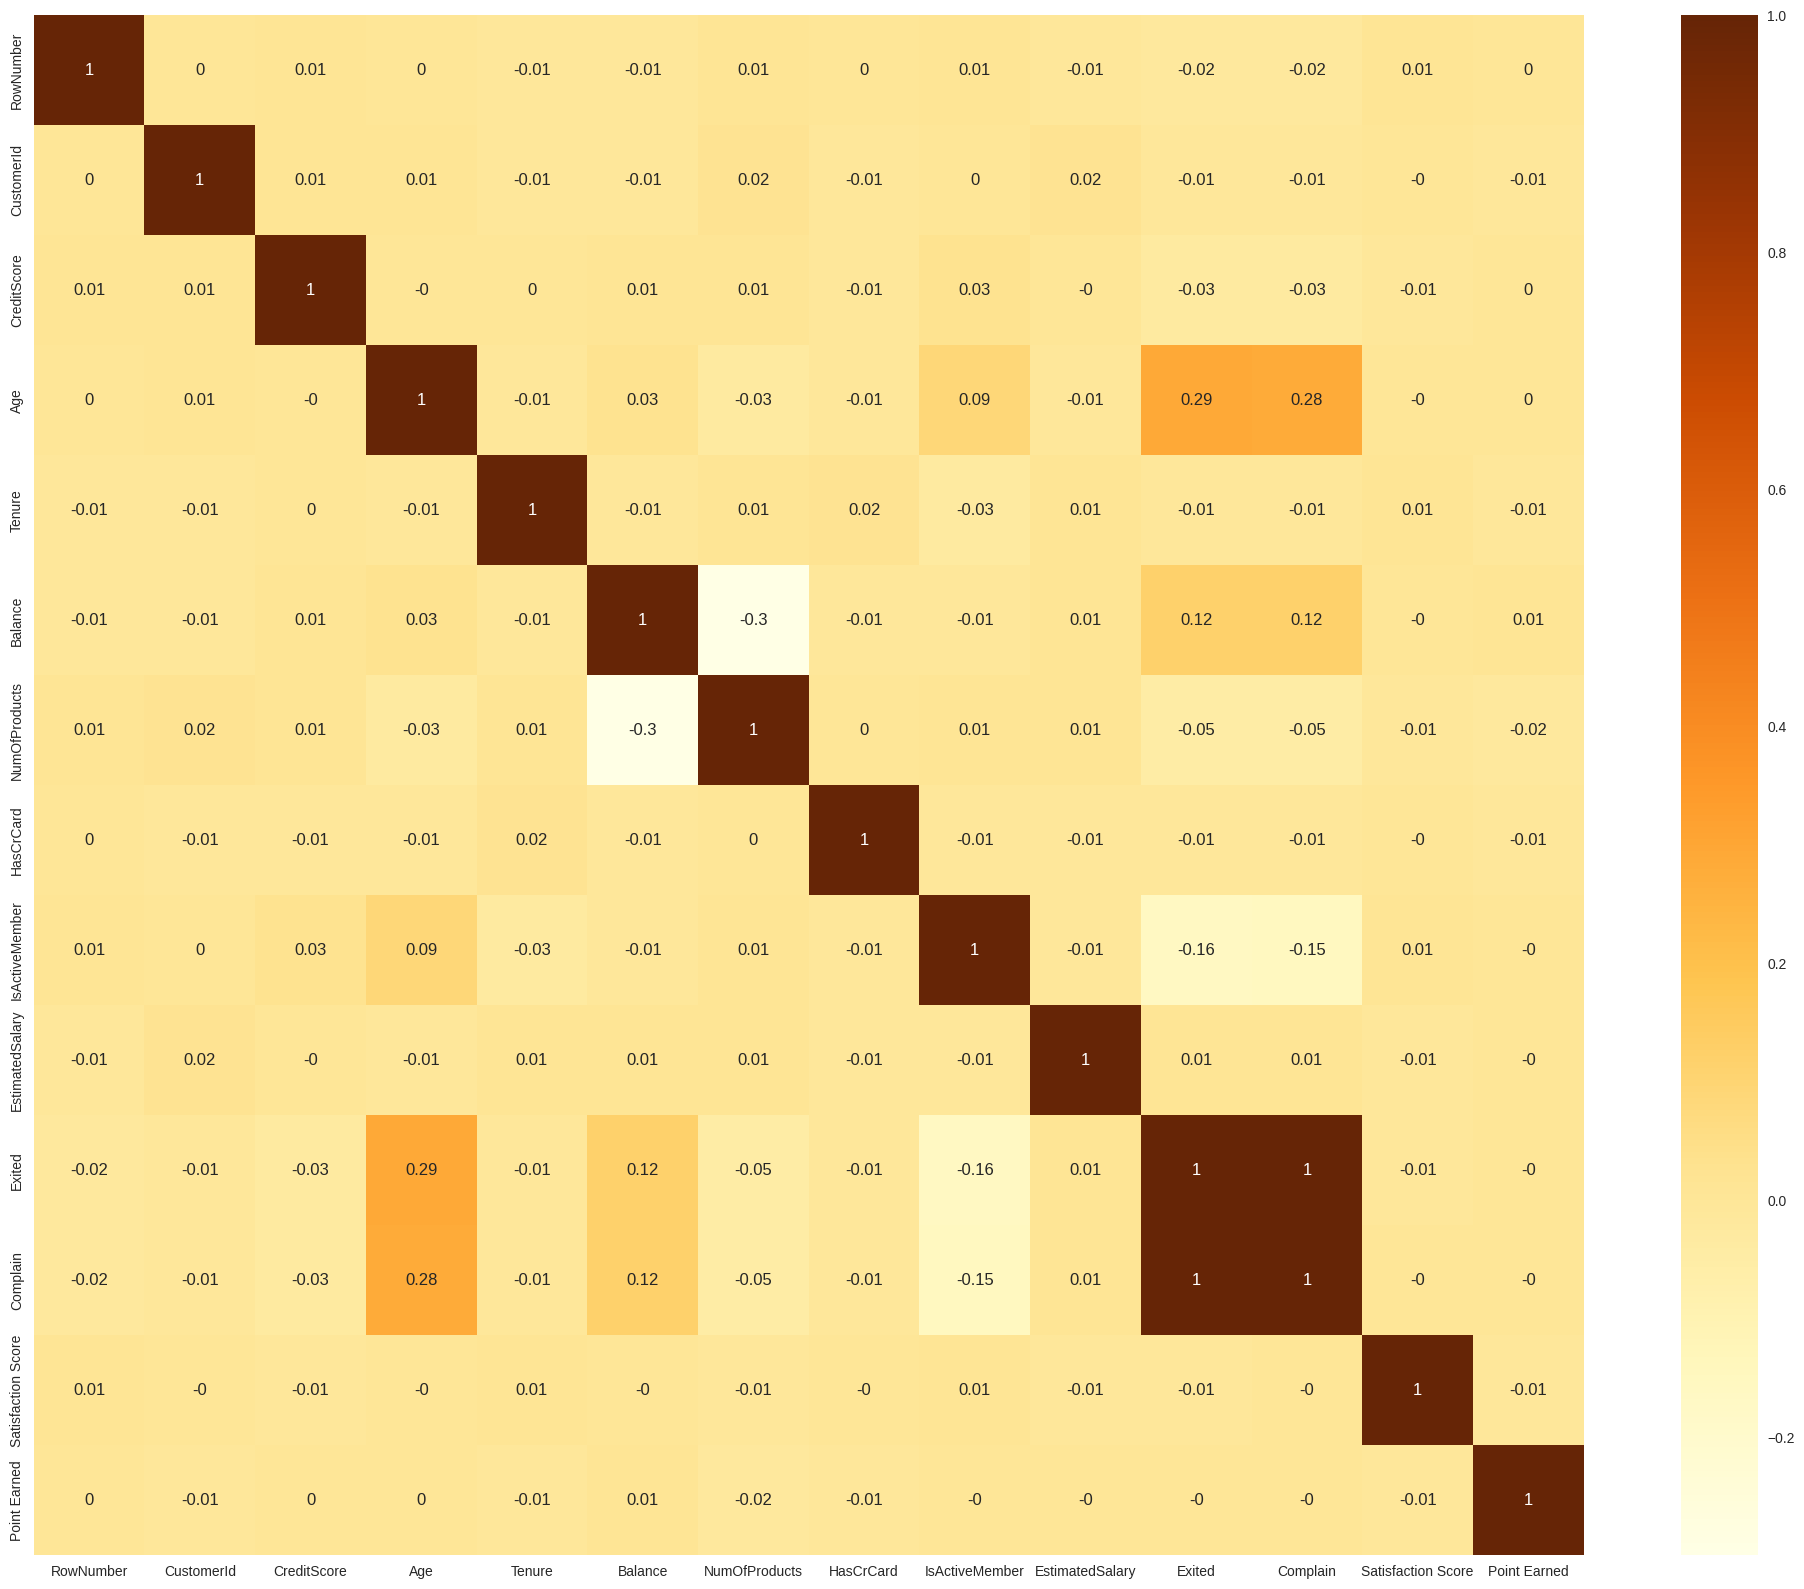

In [9]:

corr = df.corr(numeric_only=True).round(2)
plt.figure(figsize = (25,20))
sns.heatmap(corr, annot = True, cmap = 'YlOrBr')

/tmp/ipykernel_32567/1510868799.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_32567/1510868799.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_32567/1510868799.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_32567/1510868799.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue

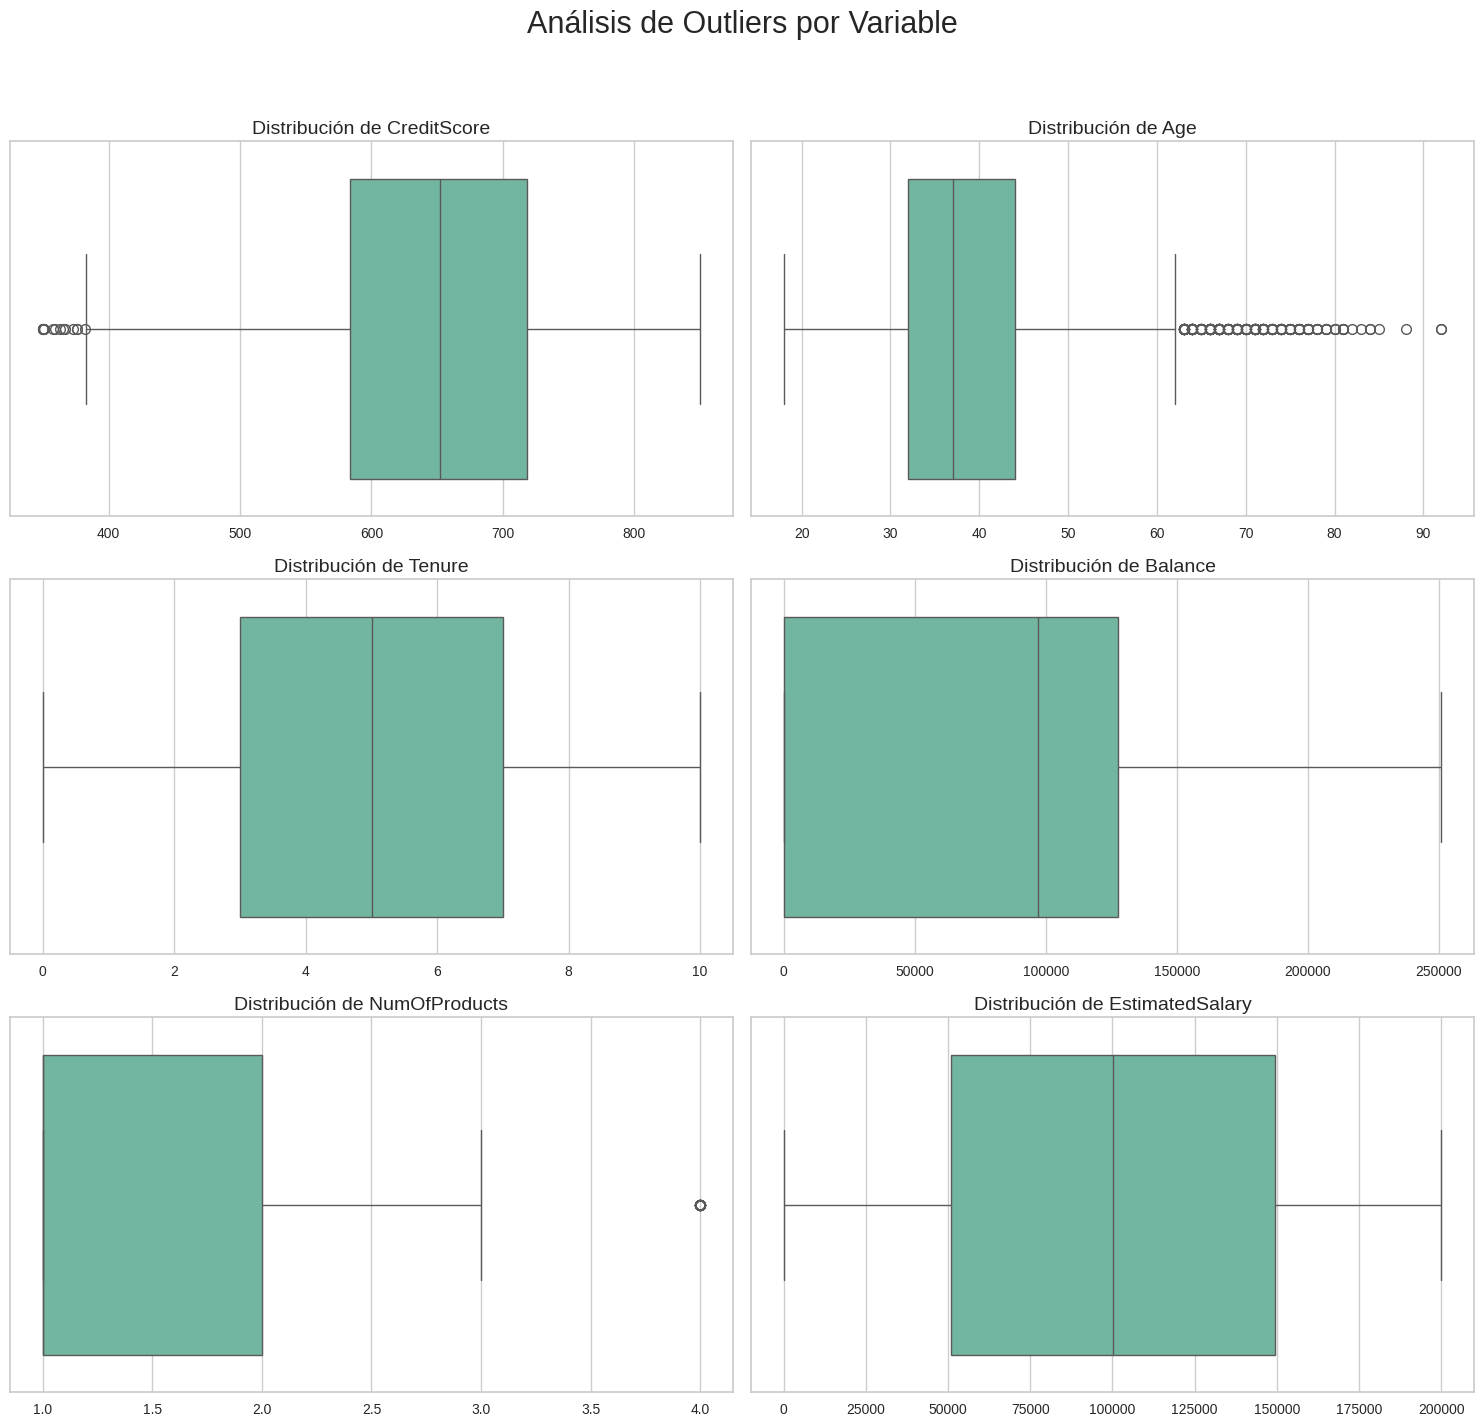

In [10]:

# Lista de variables
cols_numericas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Configuración de la cuadrícula
n_cols = 2 # Elegimos que siempre haya 2 columnas
n_rows = math.ceil(len(cols_numericas) / n_cols) # Calcula cuántas filas necesitamos

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))
fig.suptitle('Análisis de Outliers por Variable', fontsize=22)

# Ejes
axes = axes.flatten()

# Para graficar
for i, col in enumerate(cols_numericas):
    sns.boxplot(x=df[col], ax=axes[i], palette="Set2")
    axes[i].set_title(f'Distribución de {col}', fontsize=14)
    axes[i].set_xlabel('')

# Borrar cuadros vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [11]:
# =========================
# PREPARACIÓN DEL DATASET
# =========================

df_model = df.copy()

# Eliminar columnas problemáticas o irrelevantes
columnas_eliminar = ['RowNumber', 'CustomerId', 'Surname', 'Complain']
df_model = df_model.drop(columns=columnas_eliminar, errors='ignore')

# Feature engineering válido
df_model['IsZeroBalance'] = (df_model['Balance'] == 0).astype(int)

# Pasar variables categóricas a dummies
df_model = pd.get_dummies(df_model, columns=['Gender', 'Geography', 'Card Type'], drop_first=True)

# Variable objetivo
y = df_model['Exited']

# Variables base
features_base = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'IsZeroBalance', 'Satisfaction Score', 'Point Earned'
]

# Armar X sumando dummies
X = df_model[features_base].join(df_model.filter(like='Gender_')) \
                           .join(df_model.filter(like='Geography_')) \
                           .join(df_model.filter(like='Card Type_'))

print("Dimensión X:", X.shape)
print("Dimensión y:", y.shape)

Dimensión X: (10000, 17)
Dimensión y: (10000,)


In [12]:
# Entrenamiento

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8000, 17)
Test: (2000, 17)


In [13]:
# Modelo regresión logística

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.63      0.21      0.31       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000

ROC AUC: 0.7612880579367426


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
# Modelo XGB

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      1592
           1       0.73      0.50      0.60       408

    accuracy                           0.86      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000

ROC AUC: 0.8708739777317963


In [15]:
# Modelo Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.98      0.92      1592
           1       0.85      0.46      0.59       408

    accuracy                           0.87      2000
   macro avg       0.86      0.72      0.76      2000
weighted avg       0.87      0.87      0.86      2000

ROC AUC: 0.8702088875751307


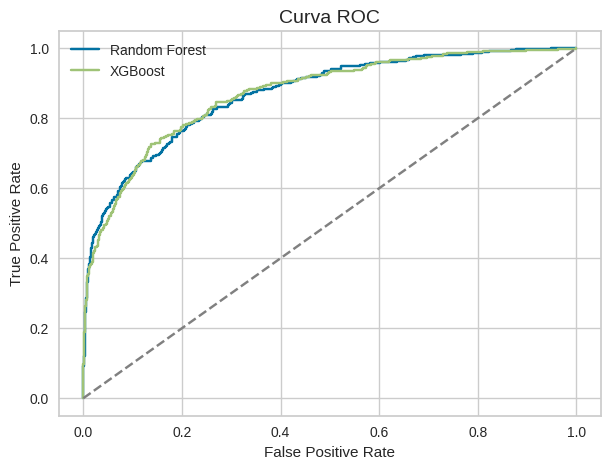

In [16]:
# Curva ROC

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.title("Curva ROC", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [17]:
threshold = 0.3
y_pred_rf_03 = (y_prob_rf >= threshold).astype(int)

print(f"=== Random Forest con threshold {threshold} ===")
print(classification_report(y_test, y_pred_rf_03))

=== Random Forest con threshold 0.3 ===
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1592
           1       0.61      0.65      0.63       408

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.84      0.85      2000



In [18]:
threshold = 0.25
y_pred_rf_025 = (y_prob_rf >= threshold).astype(int)

print(f"=== Random Forest con threshold {threshold} ===")
print(classification_report(y_test, y_pred_rf_025))

=== Random Forest con threshold 0.25 ===
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1592
           1       0.53      0.70      0.61       408

    accuracy                           0.81      2000
   macro avg       0.73      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



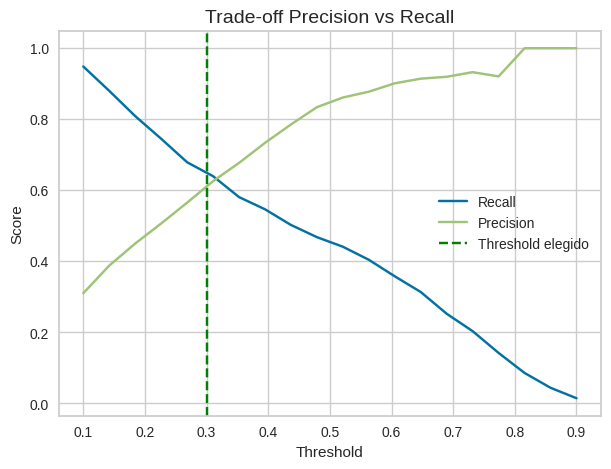

In [19]:
thresholds = np.linspace(0.1, 0.9, 20)

recalls = []
precisions = []

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    y_pred_temp = (y_prob_rf >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_temp))
    precisions.append(precision_score(y_test, y_pred_temp))

plt.figure(figsize=(7,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')

plt.axvline(x=0.3, color='green', linestyle='--', label='Threshold elegido')

plt.title("Trade-off Precision vs Recall", fontsize=14)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [20]:

# Definir threshold
threshold = 0.25

# Predicciones con threshold
y_pred_log = (y_prob_log >= threshold).astype(int)
y_pred_rf = (y_prob_rf >= threshold).astype(int)
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

# Función para calcular métricas
def evaluar_modelo(nombre, y_true, y_pred, y_prob):
    return {
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred), 3),
        'Recall': round(recall_score(y_true, y_pred), 3),
        'F1 Score': round(f1_score(y_true, y_pred), 3),
        'ROC AUC': round(roc_auc_score(y_true, y_prob), 3)
    }

# Evaluar modelos
resultados = []

resultados.append(evaluar_modelo("Regresión Logística", y_test, y_pred_log, y_prob_log))
resultados.append(evaluar_modelo("Random Forest", y_test, y_pred_rf, y_prob_rf))
resultados.append(evaluar_modelo("XGBoost", y_test, y_pred_xgb, y_prob_xgb))

# Convertir a DataFrame
tabla_modelos = pd.DataFrame(resultados)

# Ordenar por Recall (importante para tu caso)
tabla_modelos = tabla_modelos.sort_values(by='Recall', ascending=False)

tabla_modelos

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,XGBoost,0.829,0.563,0.725,0.634,0.871
1,Random Forest,0.815,0.535,0.701,0.607,0.870
0,Regresión Logística,0.744,0.414,0.610,0.493,0.761


In [21]:
# Score para todo el dataset
df_model['prob_churn'] = rf_model.predict_proba(X)[:, 1]

print(df_model['prob_churn'].describe())

count    10000.000000
mean         0.203553
std          0.218560
min          0.008932
25%          0.060983
50%          0.117243
75%          0.248040
max          0.980346
Name: prob_churn, dtype: float64


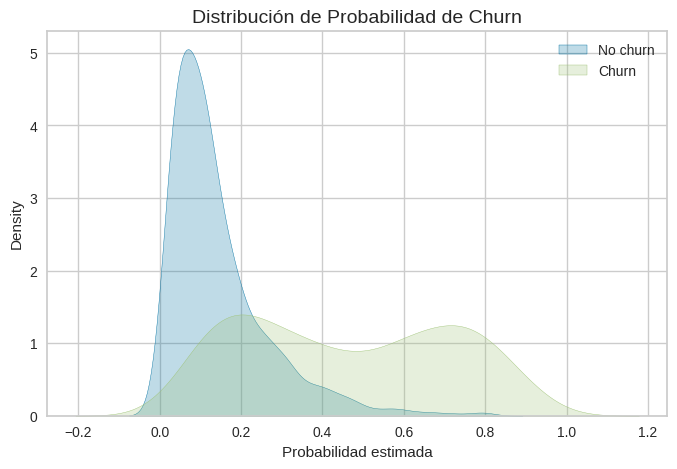

In [22]:
plt.figure(figsize=(8,5))
sns.kdeplot(y_prob_rf[y_test==0], label="No churn", fill=True)
sns.kdeplot(y_prob_rf[y_test==1], label="Churn", fill=True)

plt.title("Distribución de Probabilidad de Churn", fontsize=14)
plt.xlabel("Probabilidad estimada")
plt.legend()
plt.show()

In [23]:
# Definir grupo de clientes en riesgo según threshold operativo
threshold_cluster = 0.3

df_riesgo = df_model[df_model['prob_churn'] >= threshold_cluster].copy()

print("Cantidad de clientes en riesgo:", df_riesgo.shape[0])
print(df_riesgo[['prob_churn']].describe())

Cantidad de clientes en riesgo: 2048
        prob_churn
count  2048.000000
mean      0.576049
std       0.198095
min       0.300095
25%       0.389011
50%       0.555214
75%       0.760849
max       0.980346


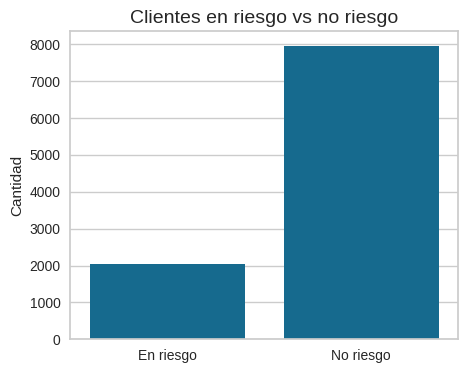

In [24]:
plt.figure(figsize=(5,4))
sns.barplot(x=['En riesgo', 'No riesgo'],
            y=[df_riesgo.shape[0], df_model.shape[0] - df_riesgo.shape[0]])

plt.title("Clientes en riesgo vs no riesgo", fontsize=14)
plt.ylabel("Cantidad")
plt.show()

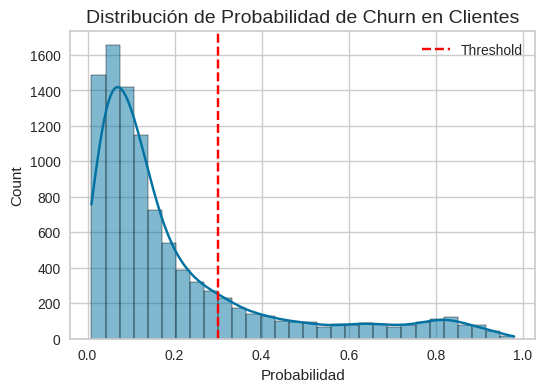

In [44]:
# Distribución de probabilidad de Churn
plt.figure(figsize=(6,4))
sns.histplot(df_model['prob_churn'], bins=30, kde=True)

plt.axvline(x=0.3, color='red', linestyle='--', label='Threshold')

plt.title("Distribución de Probabilidad de Churn en Clientes", fontsize=14)
plt.xlabel("Probabilidad")
plt.legend()
plt.show()

In [45]:
# Clustering

features_cluster = [
    'Age',
    'Balance',
    'Tenure',
    'NumOfProducts',
    'EstimatedSalary',
    'IsZeroBalance'
]

X_cluster = df_riesgo[features_cluster]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_riesgo['cluster'] = kmeans.fit_predict(X_scaled)

cluster_analysis = df_riesgo.groupby('cluster')[features_cluster].mean()
print(cluster_analysis)

               Age        Balance    Tenure  NumOfProducts  EstimatedSalary  \
cluster                                                                       
0        47.360515  121660.453004  7.562232       1.150215    109526.921788   
1        48.590504  120820.855252  2.394659       1.195846     91908.253694   
2        47.855580       0.000000  4.792123       1.483589    104098.572319   
3        43.775229  121428.400046  5.206422       3.183486    106868.734633   

         IsZeroBalance  
cluster                 
0                  0.0  
1                  0.0  
2                  1.0  
3                  0.0  


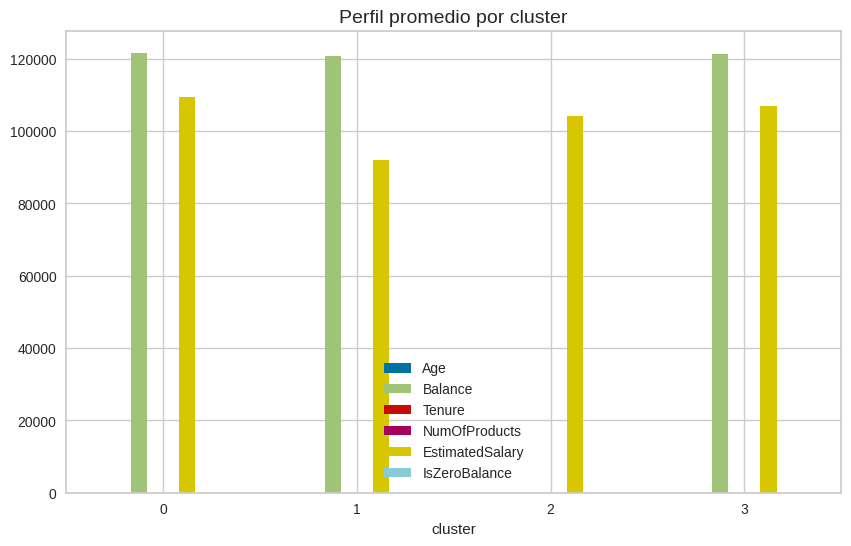

In [46]:
cluster_analysis.plot(kind='bar', figsize=(10,6))
plt.title("Perfil promedio por cluster", fontsize=14)
plt.xticks(rotation=0)
plt.show()

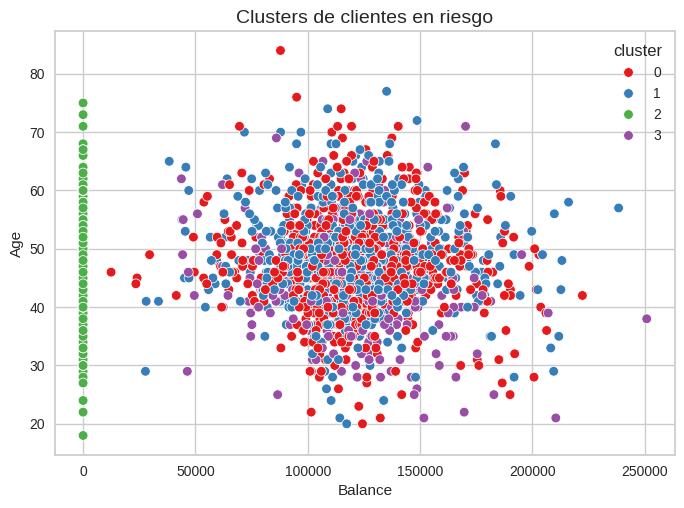

In [47]:
sns.scatterplot(
    x=df_riesgo['Balance'],
    y=df_riesgo['Age'],
    hue=df_riesgo['cluster'],
    palette='Set1'
)

plt.title("Clusters de clientes en riesgo", fontsize=14)
plt.show()

In [48]:
# Ejemplo: priorización de clientes de alto valor dentro del grupo en riesgo
clientes_criticos = df_riesgo[
    (df_riesgo['Balance'] > 95000) &
    (df_riesgo['Age'] >= 45) &
    (df_riesgo['Age'] <= 55)
].copy()

clientes_criticos = clientes_criticos.sort_values(by='prob_churn', ascending=False)

print(clientes_criticos[['cluster', 'Age', 'Balance', 'Tenure', 'NumOfProducts', 'prob_churn']].head(10))

      cluster  Age    Balance  Tenure  NumOfProducts  prob_churn
1962        3   52  143542.36       8              3    0.980346
1657        3   54  133656.91       6              3    0.965899
7257        3   47  139914.60       5              4    0.962194
2462        3   53  169406.33       9              4    0.961564
1265        3   55  116973.26       8              3    0.957580
8683        3   49  195238.29       7              4    0.955598
6279        3   55  117294.12       9              4    0.954077
6911        3   54  125889.30       3              3    0.950004
5115        3   49  102286.60       1              3    0.948010
8923        3   55  118772.71       8              4    0.942600


In [49]:
df_riesgo.groupby('cluster')['prob_churn'].mean()

,prob_churn
cluster,
0,0.524268
1,0.538664
2,0.579331
3,0.850789


In [50]:
df_riesgo_sorted = df_riesgo.sort_values(by='prob_churn', ascending=False)

df_riesgo_sorted[['cluster','Age','Balance','Tenure','NumOfProducts','prob_churn']].head(20)

,cluster,Age,Balance,Tenure,NumOfProducts,prob_churn
1962,3,52,143542.36,8,3,0.980346
4992,3,62,123681.32,9,3,0.969491
4054,3,56,115895.22,3,3,0.968431
1657,3,54,133656.91,6,3,0.965899
7257,3,47,139914.60,5,4,0.962194
2462,3,53,169406.33,9,4,0.961564
1265,3,55,116973.26,8,3,0.957580
8683,3,49,195238.29,7,4,0.955598
6279,3,55,117294.12,9,4,0.954077
3841,3,60,120731.39,2,4,0.952939


In [51]:
def asignar_intervencion(row):
    if (row['prob_churn'] > 0.6) and (row['Balance'] > 100000):
        return 'Intervencion Intensiva'
    else:
        return 'Intervencion Automatizada'

df_riesgo['tipo_intervencion'] = df_riesgo.apply(asignar_intervencion, axis=1)

/tmp/ipykernel_32567/200129014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_riesgo['tipo_intervencion'], palette="Set2")


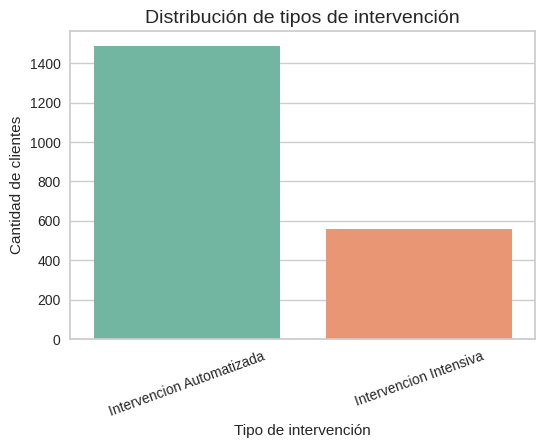

In [53]:
# Distribución de tipos de intervención
plt.figure(figsize=(6,4))
sns.countplot(x=df_riesgo['tipo_intervencion'], palette="Set2")

plt.title("Distribución de tipos de intervención", fontsize=14)
plt.xlabel("Tipo de intervención")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=20)

plt.show()

In [54]:
df_riesgo['tipo_intervencion'].value_counts()

,count
tipo_intervencion,
Intervencion Automatizada,1487
Intervencion Intensiva,561


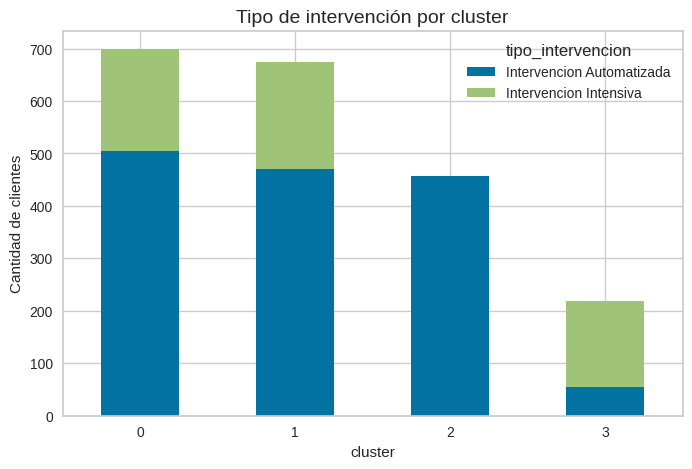

In [55]:
# Tipo de intervención por cluster
pd.crosstab(df_riesgo['cluster'], df_riesgo['tipo_intervencion']).plot(
    kind='bar', stacked=True, figsize=(8,5)
)

plt.title("Tipo de intervención por cluster", fontsize=14)
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

In [56]:
pd.crosstab(df_riesgo['cluster'], df_riesgo['tipo_intervencion'])

tipo_intervencion,Intervencion Automatizada,Intervencion Intensiva
cluster,,
0,505,194
1,470,204
2,457,0
3,55,163


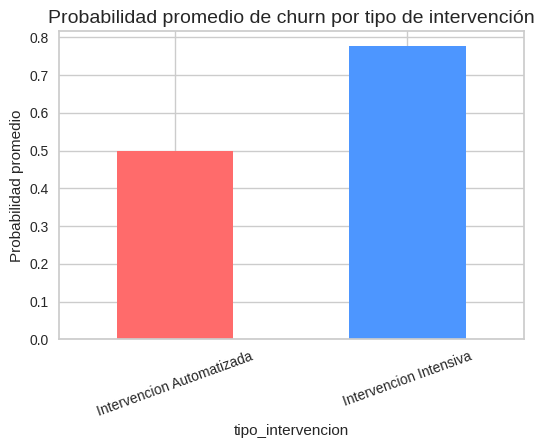

In [57]:
df_riesgo.groupby('tipo_intervencion')['prob_churn'].mean().plot(
    kind='bar',
    figsize=(6,4),
    color=['#FF6B6B','#4D96FF','#6BCB77']
)

plt.title("Probabilidad promedio de churn por tipo de intervención", fontsize=14)
plt.ylabel("Probabilidad promedio")
plt.xticks(rotation=20)

plt.show()

In [58]:
# Designar tipo de intervención
def asignar_intervencion(row):
    if (row['prob_churn'] > 0.6) and (row['Balance'] > 100000):
        return 'Intervencion Intensiva'
    elif row['IsZeroBalance'] == 1:
        return 'Intervencion Automatizada'
    else:
        return 'Intervencion Moderada'

df_riesgo['tipo_intervencion'] = df_riesgo.apply(asignar_intervencion, axis=1)

In [59]:
tabla_ejecutiva = df_riesgo.groupby('tipo_intervencion').agg({
    'prob_churn': 'mean',
    'Balance': 'mean',
    'Age': 'mean',
    'NumOfProducts': 'mean',
    'Tenure': 'mean'
}).round(2)

tabla_ejecutiva = tabla_ejecutiva.rename(columns={
    'prob_churn': 'Probabilidad promedio',
    'Balance': 'Balance promedio',
    'Age': 'Edad promedio',
    'NumOfProducts': 'Productos promedio',
    'Tenure': 'Antigüedad promedio'
})

print(tabla_ejecutiva)

                           Probabilidad promedio  Balance promedio  \
tipo_intervencion                                                    
Intervencion Automatizada                   0.58              0.00   
Intervencion Intensiva                      0.78         129914.06   
Intervencion Moderada                       0.46         116566.52   

                           Edad promedio  Productos promedio  \
tipo_intervencion                                              
Intervencion Automatizada          47.86                1.48   
Intervencion Intensiva             49.48                1.73   
Intervencion Moderada              46.25                1.30   

                           Antigüedad promedio  
tipo_intervencion                               
Intervencion Automatizada                 4.79  
Intervencion Intensiva                    5.06  
Intervencion Moderada                     5.04  


In [60]:
tabla_ejecutiva = tabla_ejecutiva.sort_values(by='Probabilidad promedio', ascending=False)

tabla_ejecutiva

,Probabilidad promedio,Balance promedio,Edad promedio,Productos promedio,Antigüedad promedio
tipo_intervencion,,,,,
Intervencion Intensiva,0.78,129914.06,49.48,1.73,5.06
Intervencion Automatizada,0.58,0.00,47.86,1.48,4.79
Intervencion Moderada,0.46,116566.52,46.25,1.30,5.04


/tmp/ipykernel_32567/4231891305.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Exited'], palette="Set2")


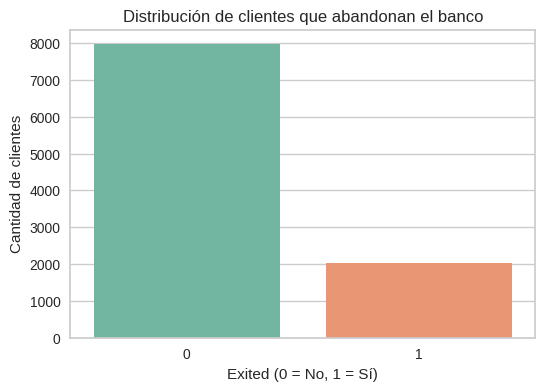

In [61]:
# Distribución de los clientes que abandonan el banco
plt.figure(figsize=(6,4))
sns.countplot(x=df['Exited'], palette="Set2")
plt.title("Distribución de clientes que abandonan el banco")
plt.xlabel("Exited (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de clientes")
plt.show()

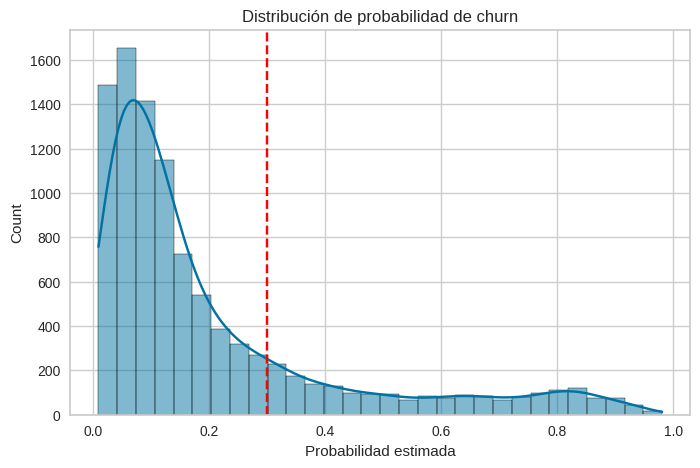

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(df_model['prob_churn'], bins=30, kde=True)

plt.axvline(x=0.3, color='red', linestyle='--')

plt.title("Distribución de probabilidad de churn")
plt.xlabel("Probabilidad estimada")
plt.show()

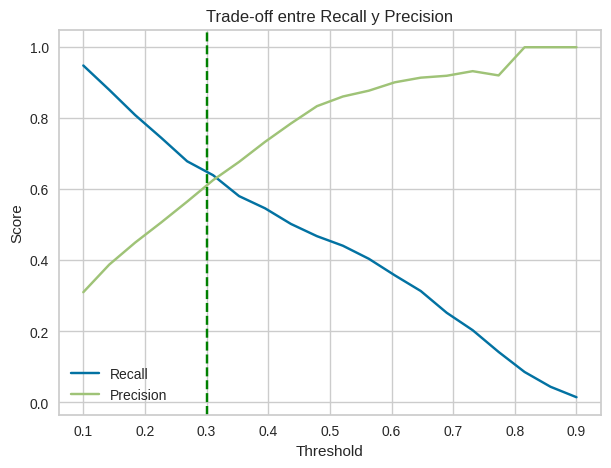

In [63]:
thresholds = np.linspace(0.1, 0.9, 20)

recalls = []
precisions = []

for t in thresholds:
    y_pred_temp = (y_prob_rf >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_temp))
    precisions.append(precision_score(y_test, y_pred_temp))

plt.figure(figsize=(7,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.axvline(x=0.3, color='green', linestyle='--')

plt.title("Trade-off entre Recall y Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

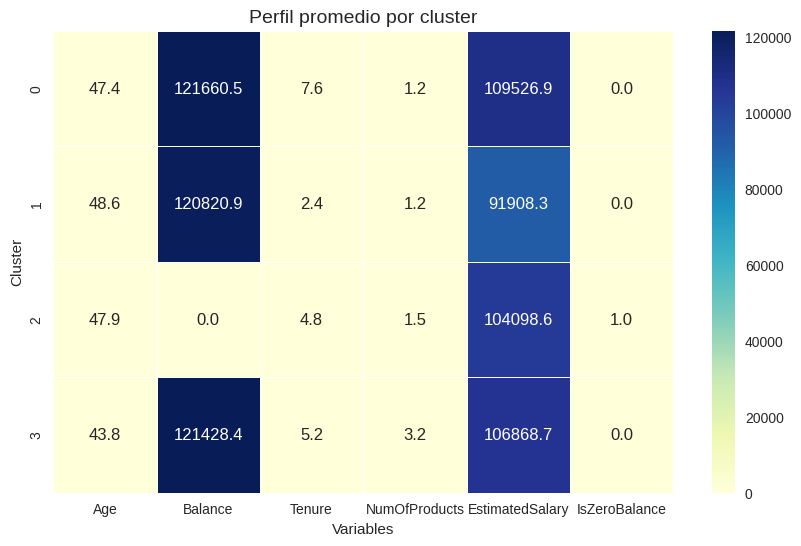

In [64]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_analysis,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Perfil promedio por cluster", fontsize=14)
plt.ylabel("Cluster")
plt.xlabel("Variables")

plt.show()

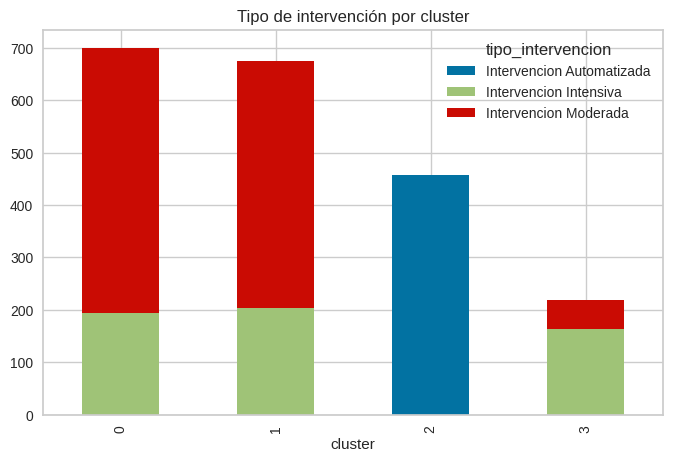

In [65]:
pd.crosstab(df_riesgo['cluster'], df_riesgo['tipo_intervencion']).plot(
    kind='bar', stacked=True, figsize=(8,5)
)

plt.title("Tipo de intervención por cluster")
plt.show()

In [66]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1592
           1       0.53      0.70      0.61       408

    accuracy                           0.81      2000
   macro avg       0.73      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000

